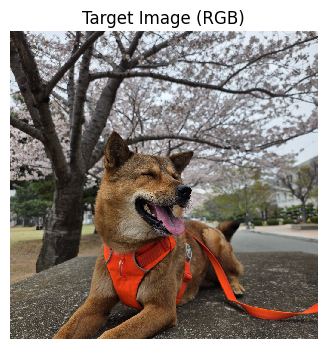

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import Video
from matplotlib.patches import Ellipse, Rectangle
import cv2
image_url = "./soondol.jpg"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
img_target = cv2.imread(image_url)
img_target = cv2.cvtColor(img_target, cv2.COLOR_BGR2RGB)
img_target = cv2.resize(img_target, (1024, 1024))
img_target = torch.tensor(img_target, dtype=torch.float32) / 255.0
def show_images(images, titles, figsize=None, vmin=0.0, vmax=1.0):
    n = len(images)
    figsize = figsize or (3.6 * n, 3.6)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    axes = [axes] if n == 1 else axes
    for ax, im, title in zip(axes, images, titles):
        if torch.is_tensor(im):
            im = im.detach().cpu().numpy()
        ax.imshow(im, vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def diff_image(a, b):
    d = torch.abs(a - b)
    mag = torch.clamp(torch.norm(d, dim=-1, keepdim=True) / np.sqrt(3.0), 0.0, 1.0)
    return d, mag.repeat(1, 1, 3)

def make_pixel_grid(H, W, device=device):
    xs = (torch.arange(W, device=device) + 0.5) / W * 2 - 1
    ys = (torch.arange(H, device=device) + 0.5) / H * 2 - 1
    Y, X = torch.meshgrid(ys, xs, indexing="ij")
    Y = torch.flip(Y, dims=[0])
    return torch.stack([X, Y], dim=-1)
from render_2dgs.cuda import render_gaussians_2d_cuda as render_gaussians_2d

# def render_gaussians_2d(H, W, mus, sigmas, thetas, opacities, rgbs, n_sigma=3.0):
#     P = make_pixel_grid(H, W, device=mus.device)
#     img = torch.zeros((H, W, 3), device=mus.device, dtype=mus.dtype)

    # for i in range(len(mus)):
    #     mu = mus[i]
    #     sigma = torch.clamp(sigmas[i], min=1e-3)
    #     theta = thetas[i]
    #     opacity = opacities[i]
    #     rgb = rgbs[i]

    #     # Axis-aligned 3σ (default) box for the rotated ellipse to cull distant pixels
    #     cos_t, sin_t = torch.cos(theta), torch.sin(theta)
    #     half_w = n_sigma * (torch.abs(cos_t) * sigma[0] + torch.abs(sin_t) * sigma[1])
    #     half_h = n_sigma * (torch.abs(sin_t) * sigma[0] + torch.abs(cos_t) * sigma[1])
    #     x0, x1 = mu[0] - half_w, mu[0] + half_w
    #     y0, y1 = mu[1] - half_h, mu[1] + half_h
    #     mask_bbox = (P[..., 0] >= x0) & (P[..., 0] <= x1) & (P[..., 1] >= y0) & (P[..., 1] <= y1)
    #     if not mask_bbox.any():
    #         continue

    #     # Gaussian evaluation only inside the bounding box
    #     R = torch.stack([torch.stack([cos_t, -sin_t]), torch.stack([sin_t, cos_t])])
    #     sigma_inv = R @ torch.diag(1.0 / (sigma ** 2)) @ R.T

    #     diff = P[mask_bbox] - mu
    #     exponent = torch.einsum("bi,ij,bj->b", diff, sigma_inv, diff)
    #     f_x = torch.exp(-0.5 * exponent)
    #     img[mask_bbox] = img[mask_bbox] + (opacity * rgb).view(1, 3) * f_x.unsqueeze(-1)

    # return torch.clamp(img, 0.0, 1.0)

show_images([img_target], ["Target Image (RGB)"])

In [ ]:

def show_image_grid(images, titles, cols=4, cell_size=3.2, vmin=0.0, vmax=1.0):
    n = len(images)
    cols = int(max(1, cols))
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cell_size * cols, cell_size * rows))
    axes = np.array(axes).reshape(rows, cols)
    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        if i < n:
            im = images[i]
            if torch.is_tensor(im):
                im = im.detach().cpu().numpy()
            ax.imshow(im, vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(titles[i])
        ax.axis("off")
    plt.tight_layout()
    plt.show()


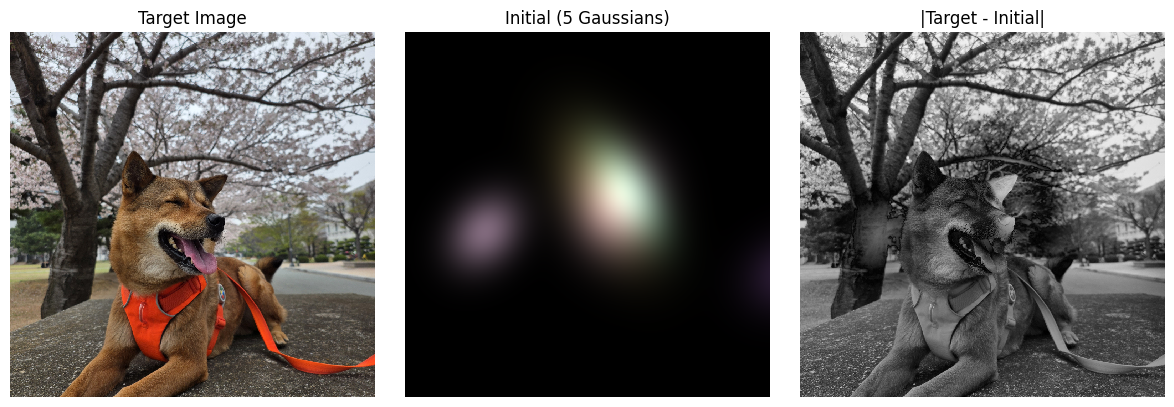

In [ ]:
# Initialize multiple random Gaussians to fit the image
num_gaussians = 20000 # Use multiple Gaussians to approximate the image

# Random initialization
torch.manual_seed(42)
init_mus = torch.randn(num_gaussians, 2) * 0.5
init_sigmas = torch.rand(num_gaussians, 2) * 0.2 + 0.1  # Random sizes
init_thetas = torch.rand(num_gaussians) * 2 * np.pi  # Random rotations [0, 2π]
init_opacities = torch.rand(num_gaussians) * 0.5 + 0.3  # Random opacities [0.3, 0.8]
init_rgbs = torch.rand(num_gaussians, 3) * 0.6 + 0.2  # Random RGB colors

img_init = render_gaussians_2d(1024, 1024, init_mus, init_sigmas, init_thetas, init_opacities, init_rgbs)
d_rgb, d_mag_img = diff_image(img_init, img_target)
show_images(
    [img_target, img_init, d_mag_img],
    ["Target Image", f"Initial ({num_gaussians} Gaussians)", "|Target - Initial|"],
    figsize=(12, 4)
)

In [11]:
import torch.nn.functional as F

def create_window(window_size, channel):
    def gaussian(window_size, sigma):
        gauss = torch.exp(torch.tensor([-(x - window_size // 2) ** 2 / float(2 * sigma ** 2) for x in range(window_size)]))
        return gauss / gauss.sum()

    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
    window = _2D_window.expand(channel, 1, window_size, window_size).contiguous()
    return window

def ssim(img1, img2, window_size=11, size_average=True):
    # Expects [H, W, C] images, converts to [1, C, H, W]
    if img1.ndim == 3:
        img1 = img1.permute(2, 0, 1).unsqueeze(0)
        img2 = img2.permute(2, 0, 1).unsqueeze(0)
    
    channel = img1.size(1)
    window = create_window(window_size, channel)
    
    if img1.is_cuda:
        window = window.cuda(img1.get_device())
    window = window.type_as(img1)

    mu1 = F.conv2d(img1, window, padding=window_size // 2, groups=channel)
    mu2 = F.conv2d(img2, window, padding=window_size // 2, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size // 2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size // 2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=window_size // 2, groups=channel) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    if size_average:
        return ssim_map.mean()
    else:
        return ssim_map.mean(1).mean(1).mean(1)

In [12]:
# Optimize multiple Gaussians to fit the image - now with rotation and pruning!
mus_param = init_mus.clone().detach().requires_grad_(True)
sigmas_param = init_sigmas.clone().detach().requires_grad_(True)
thetas_param = init_thetas.clone().detach().requires_grad_(True)
opacities_param = init_opacities.clone().detach().requires_grad_(True)
rgbs_param = init_rgbs.clone().detach().requires_grad_(True)

optimizer_img = torch.optim.Adam([mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param], lr=0.01)

# Learning rate scheduler: exponential decay
lr_decay_rate = 0.995  # Decay factor per iteration
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_img, gamma=lr_decay_rate)

history_img = []
history_lr = []  # Track learning rate
snapshots_img = []
snapshot_schedule_img = {0, 1, 10, 50, 80, 120, 160, 200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1200, 1500, 2000, 2500, 3000, 3500, 4000    }  # Iterations at which to take snapshots 



# Video frames
video_frames_img = []
video_sample_rate = 1

# Snapshot initial state
snapshots_img.append((0, mus_param.detach().clone(), sigmas_param.detach().clone(), thetas_param.detach().clone(), opacities_param.detach().clone(), rgbs_param.detach().clone()))
video_frames_img.append(img_init.detach().cpu().numpy())  # Note: img_init should be defined in previous cell

max_iters_img = 1000
densify_interval = 30
prune_interval = 10  
max_sigma_threshold = 0.3 # Threshold for splitting (and avoiding cloning)
min_opacity_threshold = 0.05  # Minimum opacity to keep a Gaussian

for it in range(max_iters_img):
    optimizer_img.zero_grad()
    
    # Clamp parameters to valid ranges
    with torch.no_grad():
        mus_param.clamp_(-1.5, 1.5)
        sigmas_param.clamp_(0.01, 1.0)
        opacities_param.clamp_(0.0, 1.0)
        rgbs_param.clamp_(0.0, 1.0)
        # No clamping for thetas - let them rotate freely
    
    # Render all Gaussians and compute loss
    rendered = render_gaussians_2d(1024, 1024, mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param)
    
    # L1 + D-SSIM loss
    lambda_dssim = 0.2
    l1_loss = torch.abs(rendered - img_target).mean()
    ssim_loss = 1.0 - ssim(rendered, img_target)
    loss = (1.0 - lambda_dssim) * l1_loss + lambda_dssim * ssim_loss
    
    # Backward pass
    loss.backward()
    
    # Save gradients before optimizer step (for cloning decision)
    mus_grad = mus_param.grad.clone() if mus_param.grad is not None else None
    
    optimizer_img.step()
    
    # Learning rate decay starts from iteration 300
    if it >= 300:
        scheduler.step()
    
    # Density control: Clone, Split, and Prune
    if (it + 1) % densify_interval == 0 or (it + 1) % prune_interval == 0:
        with torch.no_grad():
            # Densification: Clone and Split (only until iter 300)
            if (it + 1) % densify_interval == 0 and it < 300:
                prev_count = mus_param.shape[0]
                
                # 1. Clone high-gradient Gaussians (that are NOT large)
                clone_full = clone_gaussians_if_high_grad(
                    mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param,
                    mus_grad, grad_threshold=0.0002, max_sigma=max_sigma_threshold
                )
                
                # 2. Split large Gaussians
                split_full = split_gaussians_if_large(
                    clone_full[0], clone_full[1], clone_full[2], clone_full[3], clone_full[4], 
                    max_sigma=max_sigma_threshold
                )
                
                # 3. Extend the optimizer with new points
                mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param = extend_optimizer_with_new_points(
                    optimizer_img,
                    (mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param),
                    split_full,
                    prev_count,
                )
                mus_param.requires_grad_(True)
                sigmas_param.requires_grad_(True)
                thetas_param.requires_grad_(True)
                opacities_param.requires_grad_(True)
                rgbs_param.requires_grad_(True)
            
            # Pruning: Remove low-opacity Gaussians (continues throughout all training)
            if (it + 1) % prune_interval == 0:
                prune_result = prune_gaussians(
                    mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param,
                    min_opacity=min_opacity_threshold, max_sigma=None
                )
                mus_pruned, sigmas_pruned, thetas_pruned, opacities_pruned, rgbs_pruned, keep_mask = prune_result
                
                # Only update if we actually pruned something
                if keep_mask.sum() < len(mus_param):
                    mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param = remove_from_optimizer(
                        optimizer_img,
                        (mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param),
                        keep_mask
                    )
                    mus_param.requires_grad_(True)
                    sigmas_param.requires_grad_(True)
                    thetas_param.requires_grad_(True)
                    opacities_param.requires_grad_(True)
                    rgbs_param.requires_grad_(True)
    
    # Record history
    history_img.append(loss.item())
    history_lr.append(scheduler.get_last_lr()[0])
    
    # Take snapshots
    if (it + 1) in snapshot_schedule_img:
        snapshots_img.append((it + 1, mus_param.detach().clone(), sigmas_param.detach().clone(),
                             thetas_param.detach().clone(), opacities_param.detach().clone(), rgbs_param.detach().clone()))
    
    # Capture video frames
    if (it + 1) % video_sample_rate == 0:
        frame = render_gaussians_2d(1024, 1024, mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param).detach().cpu().numpy()
        video_frames_img.append(frame)
    
    if (it + 1) % 50 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Iteration {it+1}/{max_iters_img}, Loss: {loss.item():.6f}, LR: {current_lr:.6f}, Gaussians: {mus_param.shape[0]}")

# Add final frame
final_frame = render_gaussians_2d(1024, 1024, mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param).detach().cpu().numpy()
video_frames_img.append(final_frame)

print(f"Final loss: {history_img[-1]:.6f}")
print(f"Final learning rate: {history_lr[-1]:.6f}")
print(f"Final number of Gaussians: {mus_param.shape[0]} (started with {num_gaussians})")

KeyboardInterrupt: 

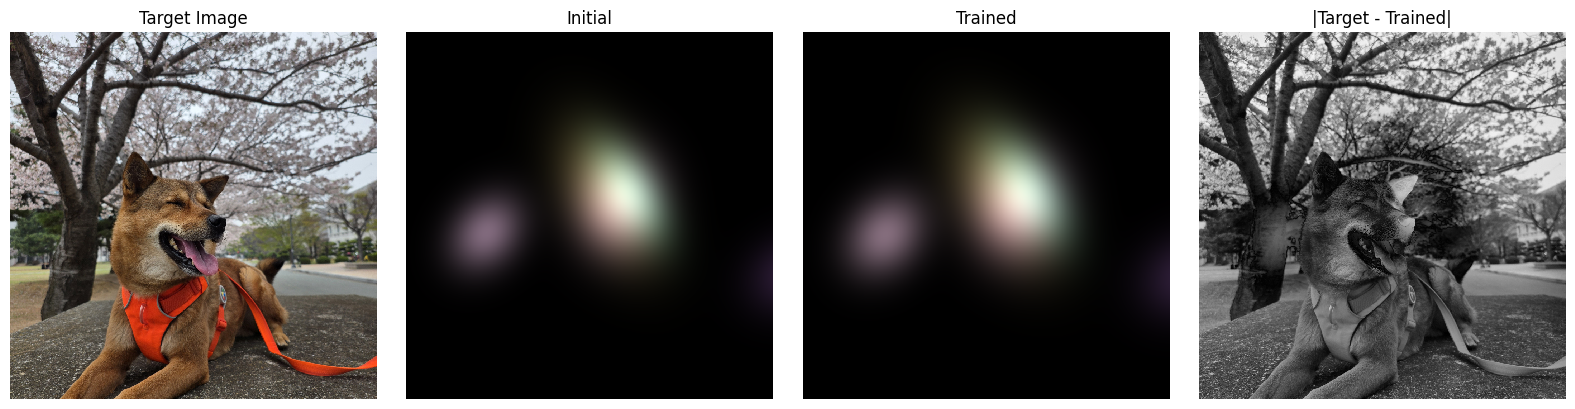

In [13]:
# Final result visualization
img_trained = render_gaussians_2d(1024, 1024, mus_param, sigmas_param, thetas_param, opacities_param, rgbs_param)
d_rgb_t, d_mag_t = diff_image(img_target, img_trained)

show_images(
    [img_target, img_init, img_trained, d_mag_t],
    ["Target Image", "Initial", "Trained", "|Target - Trained|"],
    figsize=(16, 4)
)

In [14]:
# Show training snapshots for image fitting
seen = set()
snapshots_img_unique = []
for snapshot in snapshots_img:
    it = snapshot[0]
    if it not in seen:
        snapshots_img_unique.append(snapshot)
        seen.add(it)
snapshots_img_unique.sort(key=lambda t: t[0])

snap_imgs = []
snap_titles = []
for snapshot in snapshots_img_unique:
    it, mus, sigmas, thetas, opacities, rgbs = snapshot
    snap_imgs.append(render_gaussians_2d(1024, 1024, mus, sigmas, thetas, opacities, rgbs))
    snap_titles.append(f"iter {it}")
show_image_grid(snap_imgs, snap_titles, cols=4, cell_size=3.0)

# Loss curve and learning rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history_img)
ax1.set_title(f"Loss vs Iteration (Image Fitting with Density Control)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("L1 + D-SSIM Loss")
ax1.grid(True)

ax2.plot(history_lr, color='orange')
ax2.set_title("Learning Rate Decay")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Learning Rate")
ax2.grid(True)

plt.tight_layout()
plt.show()

print("=== Optimization Results (Image Fitting with Rotation) ===")
print(f"Number of Gaussians: {num_gaussians}")
print(f"Initial loss: {history_img[0]:.6f}")
print(f"Final loss: {history_img[-1]:.6f}")
print(f"Improvement: {(1 - history_img[-1]/history_img[0]) * 100:.2f}%")
print(f"Initial LR: {history_lr[0]:.6f}, Final LR: {history_lr[-1]:.6f}")

print("Key insight: Rotated Gaussians can better approximate oriented features!")
print("Full 2×2 covariance matrices allow alignment with image details.")

NameError: name 'show_image_grid' is not defined

In [15]:
# Save and display training video for image fitting
print(f"Creating video with {len(video_frames_img)} frames...")
save_training_video(video_frames_img, "gaussian_image_training.mp4", fps=30, 
                   title=f"Image Fitting with {num_gaussians} Gaussians")
Video("gaussian_image_training.mp4", embed=True, width=600)

Creating video with 1 frames...


NameError: name 'save_training_video' is not defined

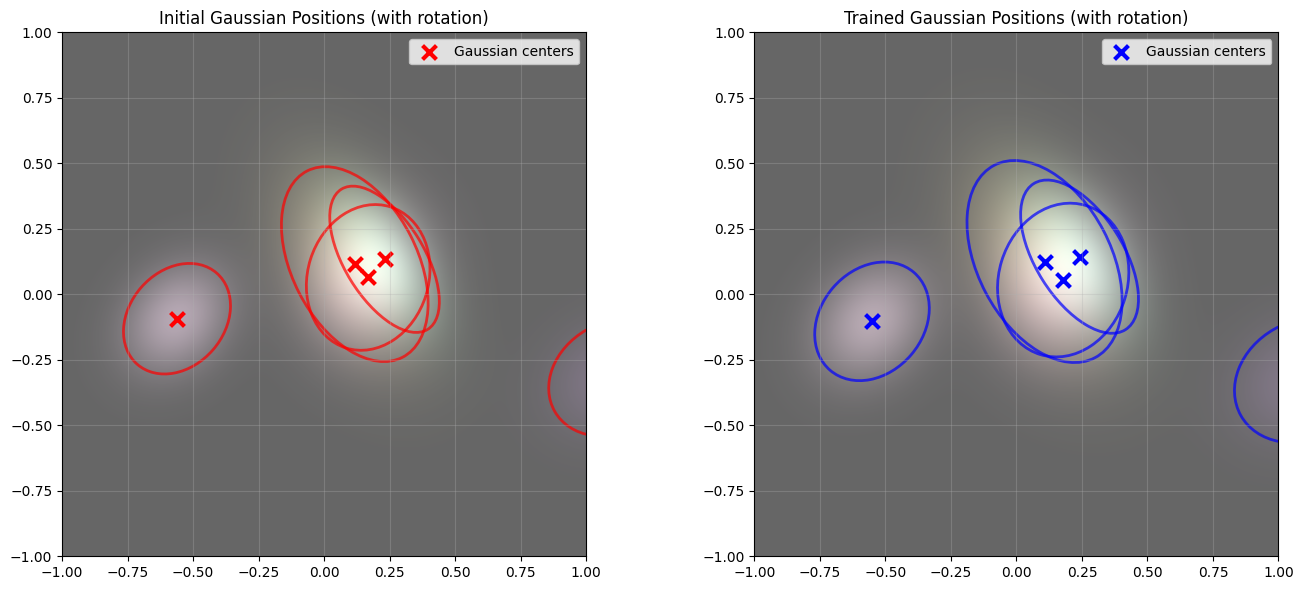

In [16]:
# Visualize Gaussian positions and their evolution with rotation
from matplotlib.patches import Ellipse

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Initial positions (normalized to [-1,1] for visualization)
mus_np_init = init_mus.detach().cpu().numpy()
img_init_normalized = img_init / img_init.max()
ax1.imshow(img_init_normalized.detach().cpu().numpy(), extent=[-1, 1, -1, 1], origin='upper', alpha=0.6)
ax1.scatter(mus_np_init[:, 0], mus_np_init[:, 1], c='red', s=100, marker='x', linewidths=3, label='Gaussian centers')
for i in range(num_gaussians):
    ellipse = Ellipse(
        (mus_np_init[i, 0], mus_np_init[i, 1]),
        width=init_sigmas[i, 0].item() * 3,
        height=init_sigmas[i, 1].item() * 3,
        angle=np.degrees(init_thetas[i].item()),  # Convert radians to degrees
        edgecolor='red',
        facecolor='none',
        linewidth=2,
        alpha=0.7
    )
    ax1.add_patch(ellipse)
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_aspect('equal')
ax1.set_title('Initial Gaussian Positions (with rotation)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Final positions (normalized to [-1,1] for visualization)
mus_np = mus_param.detach().cpu().numpy()
img_trained_normalized = img_trained / img_trained.max()
ax2.imshow(img_trained_normalized.detach().cpu().numpy(), extent=[-1, 1, -1, 1], origin='upper', alpha=0.6)
ax2.scatter(mus_np[:, 0], mus_np[:, 1], c='blue', s=100, marker='x', linewidths=3, label='Gaussian centers')
for i in range(len(mus_param)):  # draw ellipses for all current Gaussians after splits
    ellipse = Ellipse(
        (mus_np[i, 0], mus_np[i, 1]),
        width=sigmas_param[i, 0].item() * 3,
        height=sigmas_param[i, 1].item() * 3,
        angle=np.degrees(thetas_param[i].item()),  # Convert radians to degrees
        edgecolor='blue',
        facecolor='none',
        linewidth=2,
        alpha=0.7
    )
    ax2.add_patch(ellipse)
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_aspect('equal')
ax2.set_title('Trained Gaussian Positions (with rotation)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

